In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import scanpy as sc

from cellina import CellinaModel
from utils import set_seed

/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Get dataset

In [3]:
set_seed(0)

In [4]:
#adata = sc.read_h5ad("/data2/a330d/datasets/synthetic_spatial_adata_processed.h5ad")
adata = sc.read("/data/a330d/projects/dsa/data/melanoma_cosmx_processed.h5ad")

In [5]:
seeds = range(5)

In [6]:
# Set holdout set for evaluation
fraction = 0.1
n_cells = adata.n_obs
n_holdout = int(n_cells * fraction)

# Randomly choose cells
holdout_idx = np.random.choice(n_cells, n_holdout, replace=False)

# Set 'is_holdout' to False by default, then True for selected cells
adata.obs['is_holdout'] = False
adata.obs.iloc[holdout_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [7]:
adata_train = adata[~adata.obs["is_holdout"]].copy()

In [8]:
"""
CellinaModel.setup_anndata(adata_train,
                           batch_key="batch",
                           labels_key='cell_type', 
                           domains_key='region', 
                           spatial_obsm_key="spatial_x",
                           layer='counts')
"""

CellinaModel.setup_anndata(adata_train,
                           batch_key="CPID_str",
                           labels_key='celltype', 
                           domains_key='BEST_RESPONSE_BY_SCAN', 
                           spatial_obsm_key="neighborhood_pseudobulks")

INFO     Generating sequential column names                                                                        


In [9]:
base_path = "/data2/a330d/data/cellina-reproducibility"

In [10]:
epochs = 100
conditions = [True, False]
for cond in conditions:
    for seed in seeds:
        set_seed(seed)
        model = CellinaModel(
            adata_train, n_latent=64, classifier_lambda=1e5, discriminator_lambda=5e5, condition_on_intrinsic=cond
        )
        model.train(
            max_epochs=epochs,
            check_val_every_n_epoch=1,
            early_stopping=True,
            early_stopping_patience=25,
            early_stopping_monitor="validation_loss",  # NOTE: z/e kl + reconstruction
            train_size=0.9,
            validation_size=0.1,
            plan_kwargs={
                "lr": 0.0001,
                "weight_decay": 0.0001,
            },
            enable_checkpointing=True,
            batch_size=2048,
            devices=[1],
        )

        model.save(f"{base_path}/trained/cond_z_{cond}_seed_{seed}", overwrite=True)    

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be

Epoch 100/100: 100%|██████████| 100/100 [02:27<00:00,  1.46s/it, v_num=1, train_loss=-4.46e+5]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [02:27<00:00,  1.47s/it, v_num=1, train_loss=-4.46e+5]
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


...

Epoch 100/100: 100%|██████████| 100/100 [02:17<00:00,  1.38s/it, v_num=1, train_loss=-4.44e+5]
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 100/100: 100%|██████████| 100/100 [02:17<00:00,  1.35s/it, v_num=1, train_loss=-4.5e+5] 

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [02:17<00:00,  1.38s/it, v_num=1, train_loss=-4.5e+5]


# Evaluate Marginal LL via Importance Sampling to see holdout data fit

In [11]:
root_dir=f"{base_path}/trained"

In [12]:
results = {str(cond): [] for cond in conditions}
for cond in conditions:
    for seed in seeds:
        set_seed(seed)
        save_path = f"{root_dir}/cond_z_{cond}_seed_{seed}"

        model = CellinaModel.load(save_path, adata)

        mll = model.get_marginal_ll(adata=adata[adata.obs['is_holdout']], n_mc_samples=1000, reduce='mean')
        results[str(cond)].append(mll)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/trained/cond_z_True_seed_0/model.pt already downloaded     
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 3 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/trained/cond_z_True_seed_1/model.pt already downloaded     
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 3 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


...

/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 3 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/trained/cond_z_False_seed_3/model.pt already downloaded    
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 3 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/trained/cond_z_False_seed_4/model.pt already downloaded    
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 3 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(


In [16]:
import pickle

with open(f"results/mll_melanoma_ablation_results.pkl", "wb") as f:
    pickle.dump(results, f)

# Plot

In [23]:
with open(f"{base_path}/mll_ablation_results.pkl", "rb") as f:
    results = pickle.load(f)

/tmp/ipykernel_3478629/428128239.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


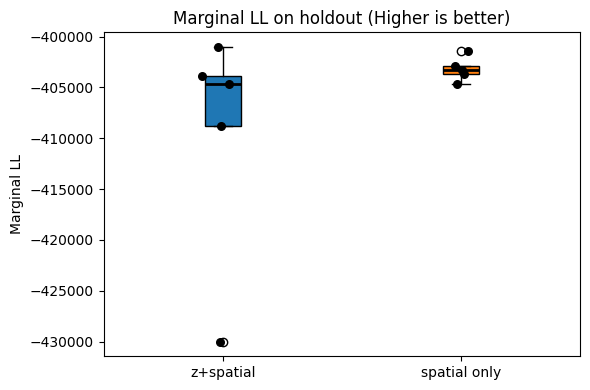

In [24]:
import matplotlib.pyplot as plt

conditions = list(results.keys())
data = [results[c] for c in conditions]

# Assign a color per condition
colors = ["tab:blue", "tab:orange"]   # add or change colors as needed
x_labels = ["z+spatial", "spatial only"] # Rename labels for plotting

fig, ax = plt.subplots(figsize=(6, 4))

bp = ax.boxplot(
    data,
    patch_artist=True,   # allows facecolor
    labels=x_labels,
    medianprops=dict(color='black', linewidth=2)
)

# Apply colors to each box
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Optional: jittered points overlaid on the boxes
for i, cond in enumerate(conditions):
    y = np.array(results[cond])
    x = np.random.normal(i+1, 0.04, size=len(y))   # jitter for visibility
    ax.scatter(x, y, color="black", s=30, zorder=3)

ax.set_ylabel("Marginal LL")
ax.set_title("Marginal LL on holdout (Higher is better)")

plt.tight_layout()
plt.show()

/tmp/ipykernel_3482370/428128239.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


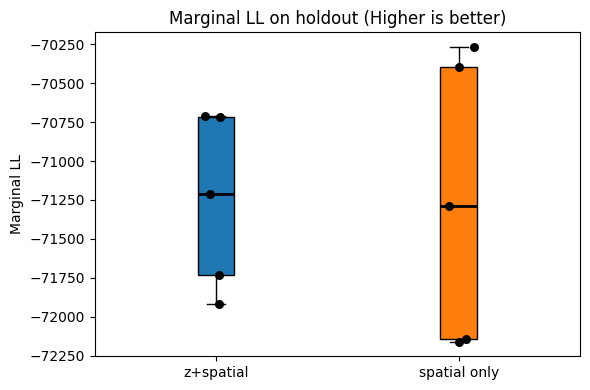

In [15]:
import matplotlib.pyplot as plt

conditions = list(results.keys())
data = [results[c] for c in conditions]

# Assign a color per condition
colors = ["tab:blue", "tab:orange"]   # add or change colors as needed
x_labels = ["z+spatial", "spatial only"] # Rename labels for plotting

fig, ax = plt.subplots(figsize=(6, 4))

bp = ax.boxplot(
    data,
    patch_artist=True,   # allows facecolor
    labels=x_labels,
    medianprops=dict(color='black', linewidth=2)
)

# Apply colors to each box
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Optional: jittered points overlaid on the boxes
for i, cond in enumerate(conditions):
    y = np.array(results[cond])
    x = np.random.normal(i+1, 0.04, size=len(y))   # jitter for visibility
    ax.scatter(x, y, color="black", s=30, zorder=3)

ax.set_ylabel("Marginal LL")
ax.set_title("Marginal LL on holdout (Higher is better)")

plt.tight_layout()
plt.show()